<h1> Image compression using Discrete Wavelet Transform (DWT) (WIP) </h1>

In this notebook, I will perform image compression using the common wavelet technique. The function implementation is in the `impro_util.py` script.

Some linear algebra knowledge is assumed in this notebook, such as matrix diagonalization and basic matrix operations. Pre-requisite knowledge of series and summations is also assumed.

Note this only works for grayscale images. The following YouTube video presents a good tutorial: https://www.youtube.com/watch?v=eJLF9HeZA8I

In [1]:
# Import statements
import numpy as np
import pywt
import matplotlib.pyplot as plt
import impro_utils as imp

plt.rcParams.update({'font.size': 40})

<h3> Loading image </h3>

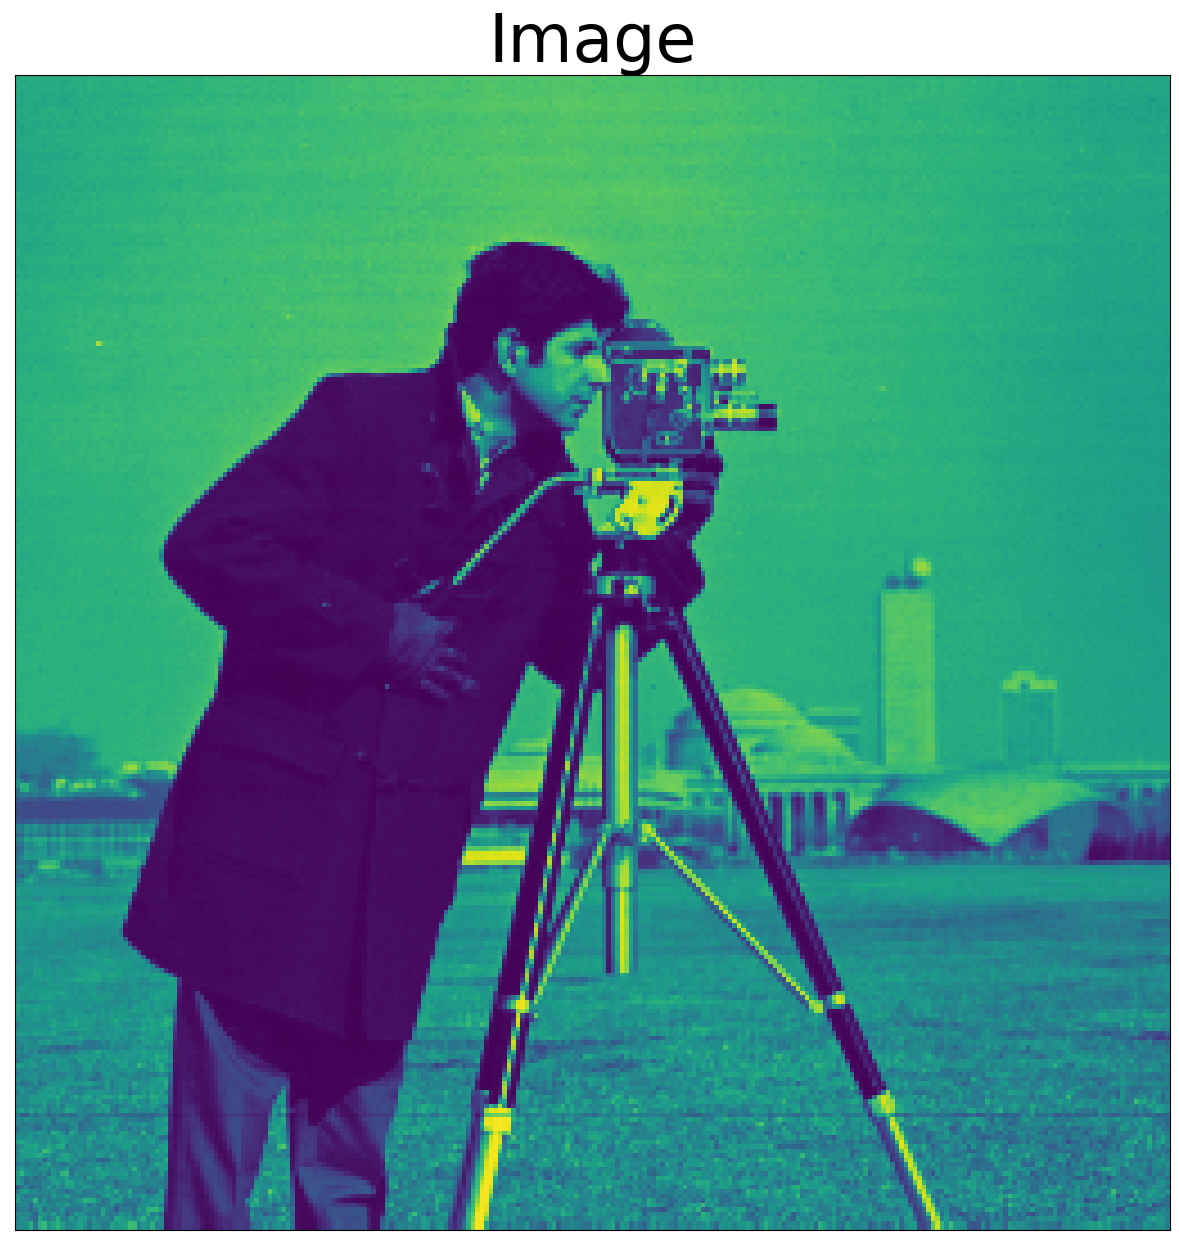

In [2]:
filename = 'images/test2.jpg'
image = imp.load_data(filename)

fig = plt.figure(figsize=(20,15))
imp.plot_img(image, "Image")

<h3> What is the  Wavelet Transform (WT)? WIP </h3>

The Wavelet Transform (WT) is an operation by which an input is separated into individual components, notably a summation of basis functions consisting of wavelets affixed with an intensity constant. Mathematically, the 2D  continuous WT can be represented as:

$$ \Chi(a,b) = \frac{1}{\sqrt{a}}\int_{-\infty}^{\infty} \overline{\Psi\left(\frac{t-b}{a}\right)} x(t) dt $$

where:

$$ a =  2^{-j} $$
    
and

$$ b = k2^{-j} $$

$j$ is refered to as the scale parameter and $k$ is the shift parameter.

The Discrete Wavelet Transform (DWT) in 2D



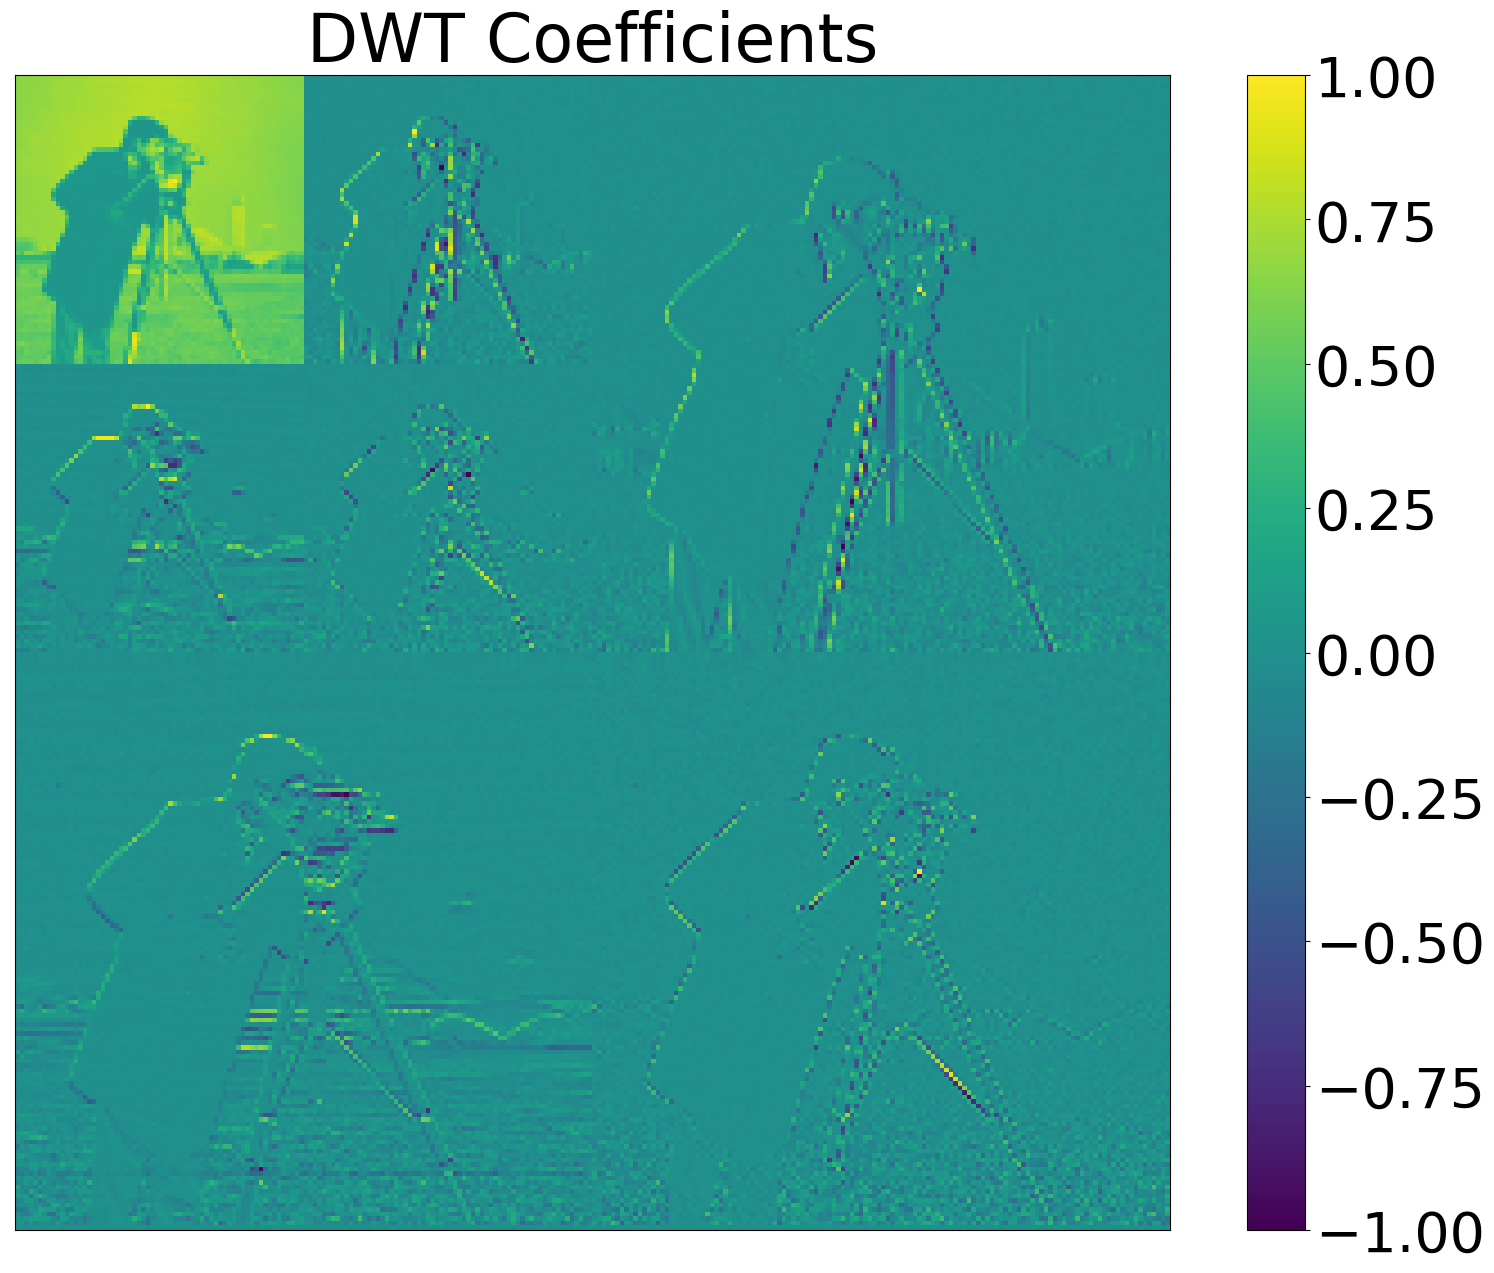

In [27]:
wvlt = 'db1'
lvl = 2
wvlt_coeffs = pywt.wavedec2(image, wavelet=wvlt, level=lvl)

# Normalization of coefficients for visualization
wvlt_coeffs[0] /= np.abs(wvlt_coeffs[0]).max()
for i in range(lvl):
    wvlt_coeffs[i+1] = [d/np.abs(d).max() for d in wvlt_coeffs[i+1]]

wvlt_array, coeff_slices = pywt.coeffs_to_array(wvlt_coeffs)

fig = plt.figure(figsize=(20,15))
imp.plot_img(wvlt_array, "DWT Coefficients")
plt.colorbar()

<h3> Performing DWT compression </h3>

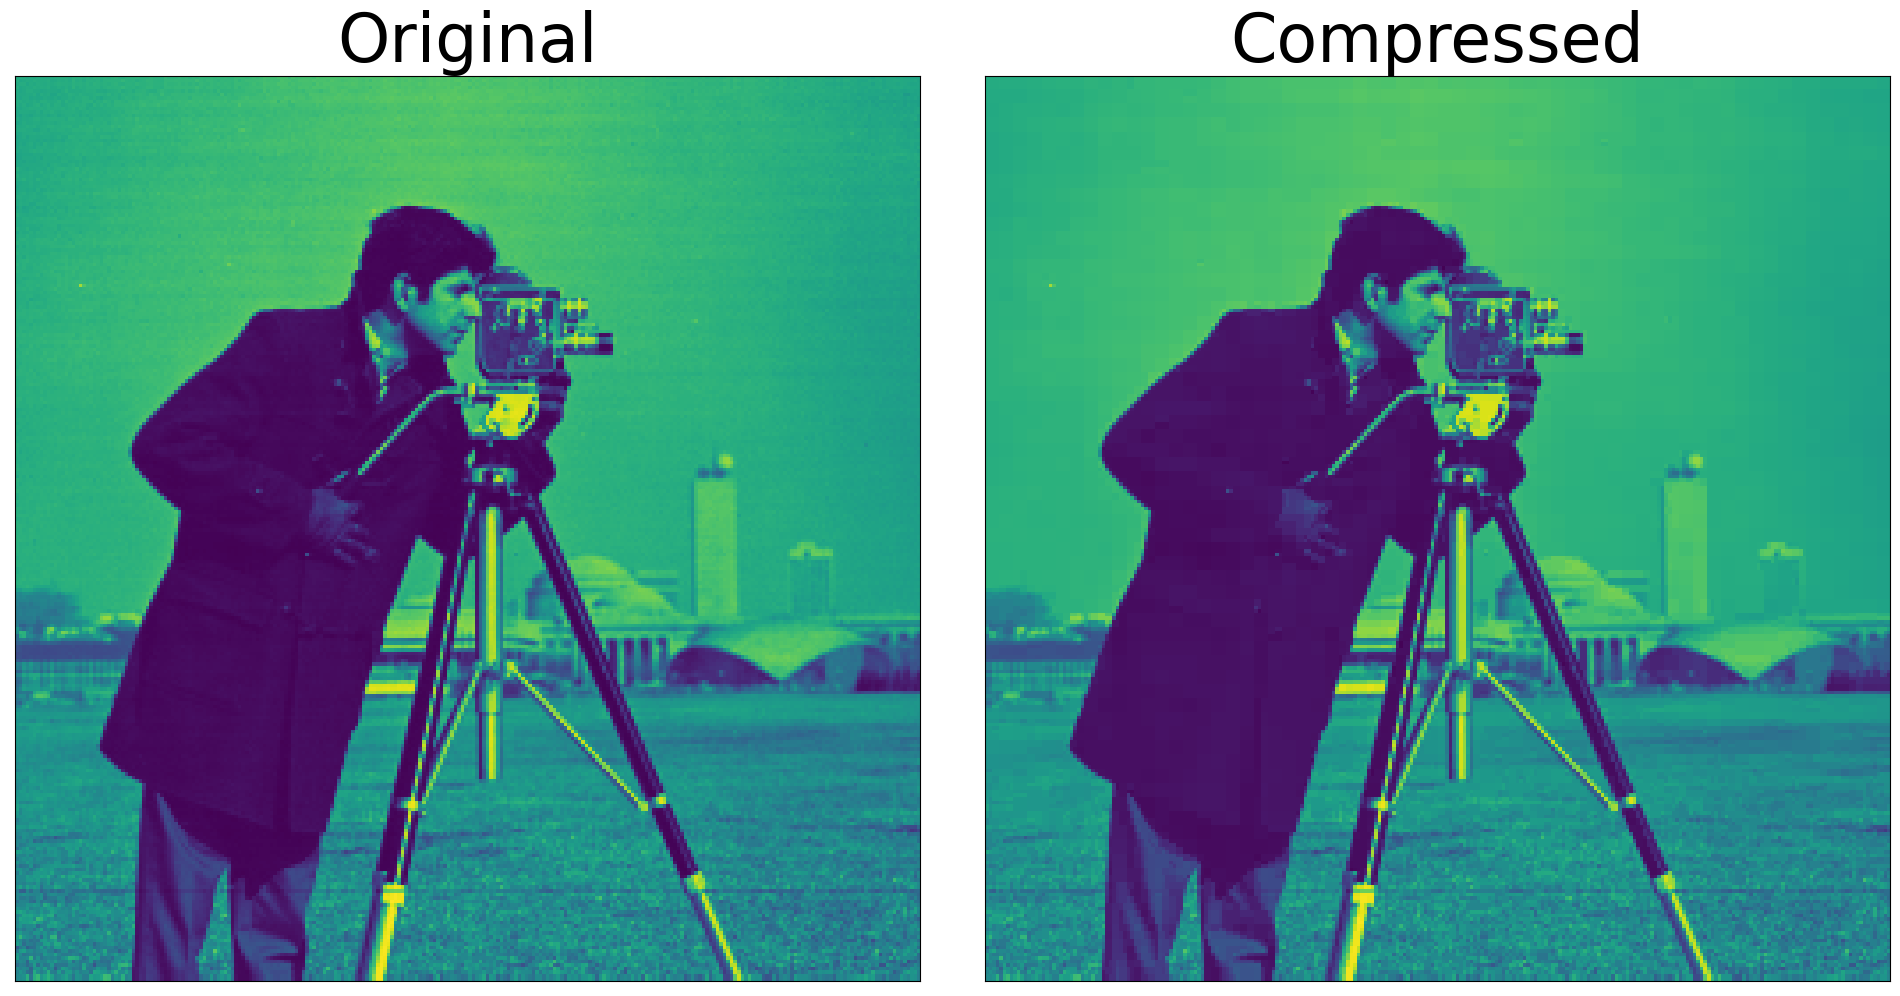

In [69]:
wvlt = 'db1'
lvl = 2
wvlt_coeffs = pywt.wavedec2(image, wavelet=wvlt, level=lvl)

wvlt_array, coeff_slices = pywt.coeffs_to_array(wvlt_coeffs)
thresh = max(abs(wvlt_array).flatten())*0.01

# Filtering threshold to reduce quantity of data in reconstruction
wvtl_thresh = wvlt_array * (abs(wvlt_array) > thresh) # Threshold small indices

coeffs_filt = pywt.array_to_coeffs(wvtl_thresh,coeff_slices,output_format='wavedec2')
inv_wvlt = pywt.waverec2(coeffs_filt,wavelet=wvlt)


fig = plt.figure(figsize=(20,15))
plt.subplot(1,2,1)
imp.plot_img(image,'Original')
plt.subplot(1,2,2)
imp.plot_img(inv_wvlt,'Compressed')
plt.tight_layout()

<h3> Displaying results </h3>

Shown on the right is the compressed version of the image on the left. Note the image artifacts! A 50x50 grid of the original 256x256 DCT coefficients were used in the compressed image (decrease of 94%). Although the result has similar shape to the original image, it is far too pixelated to be of value. In this way, DCT is known as a "lossy" form of compression leading to degradation of the image in its compressed representation due to inexact approximations.

Taking a 100x100 grid instead gives a better result, which still represents a decrease of 85% of the original number of coefficients.

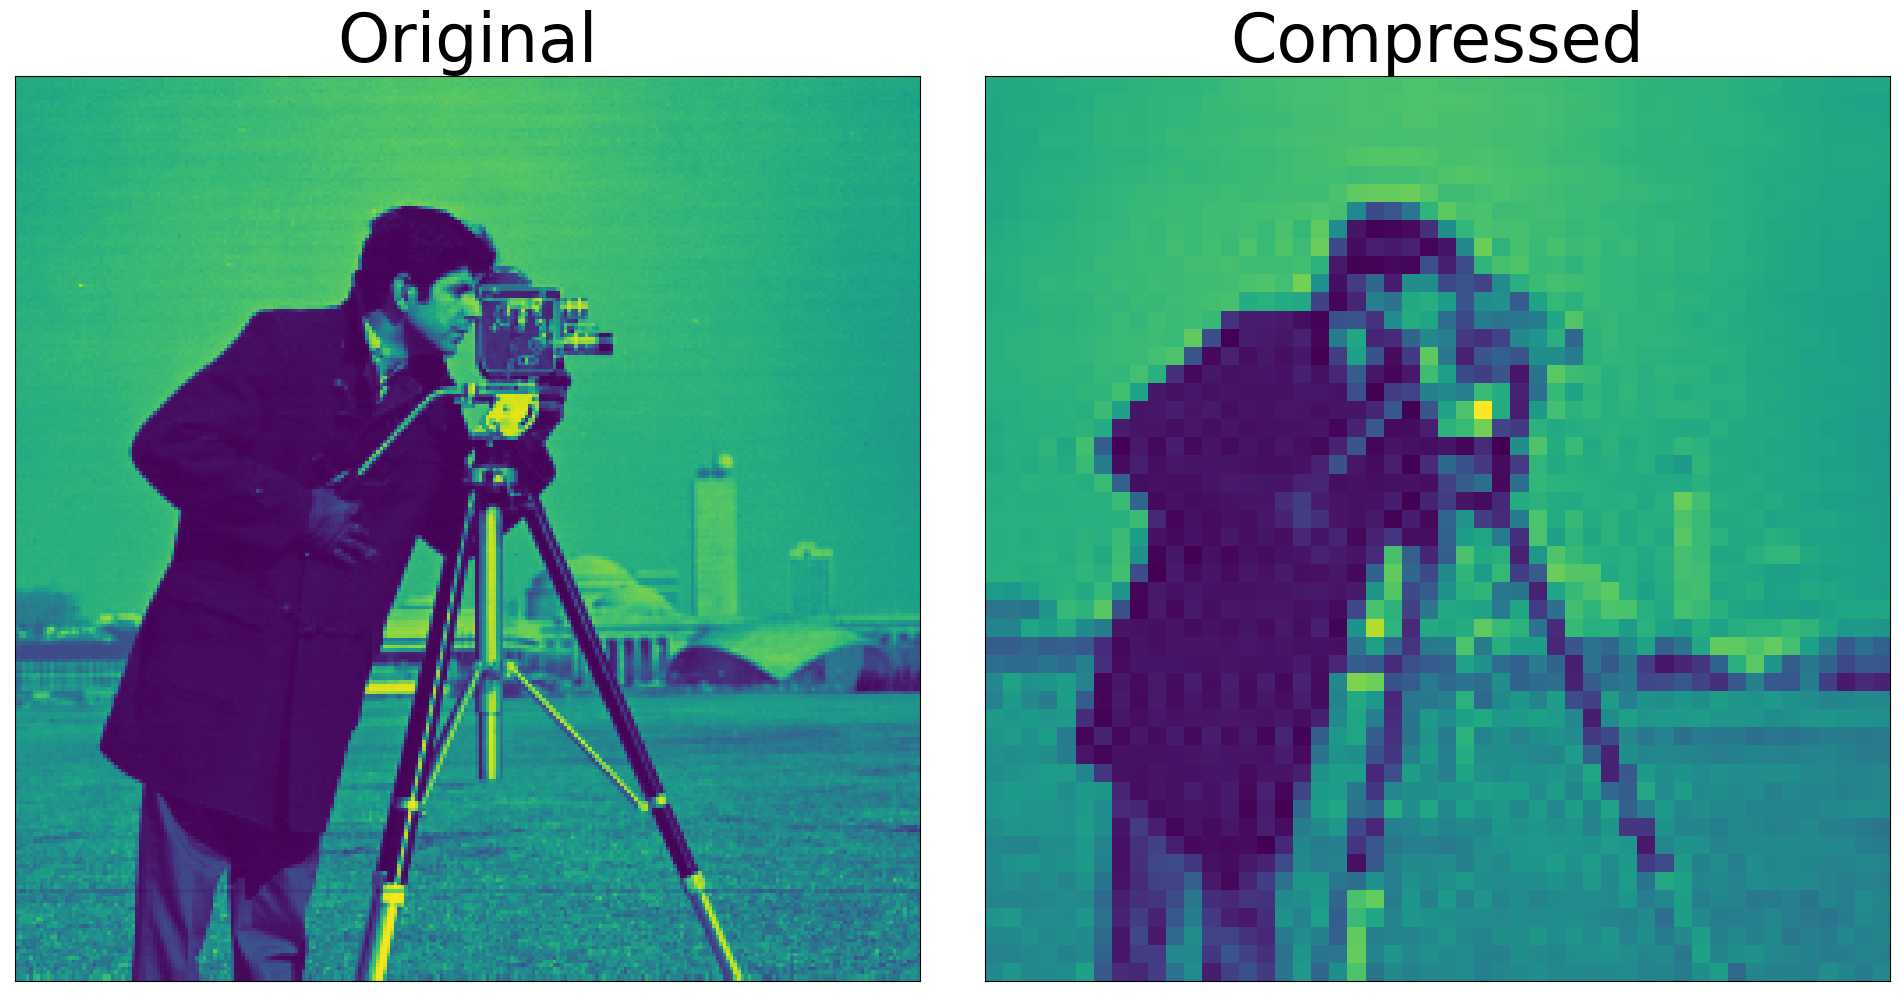

In [11]:
inv_dct = idctn(dct_coeffs[0:50,0:50], norm='ortho')

fig = plt.figure(figsize=(20,15))
plt.subplot(1,2,1)
imp.plot_img(abs(image),'Original')
plt.subplot(1,2,2)
imp.plot_img(abs(inv_dct),'Compressed')
plt.tight_layout()

<h3> Different levels of compression... </h3>

Experimenting with different numbers of grid sizes shows just how powerful this technique is for compression.

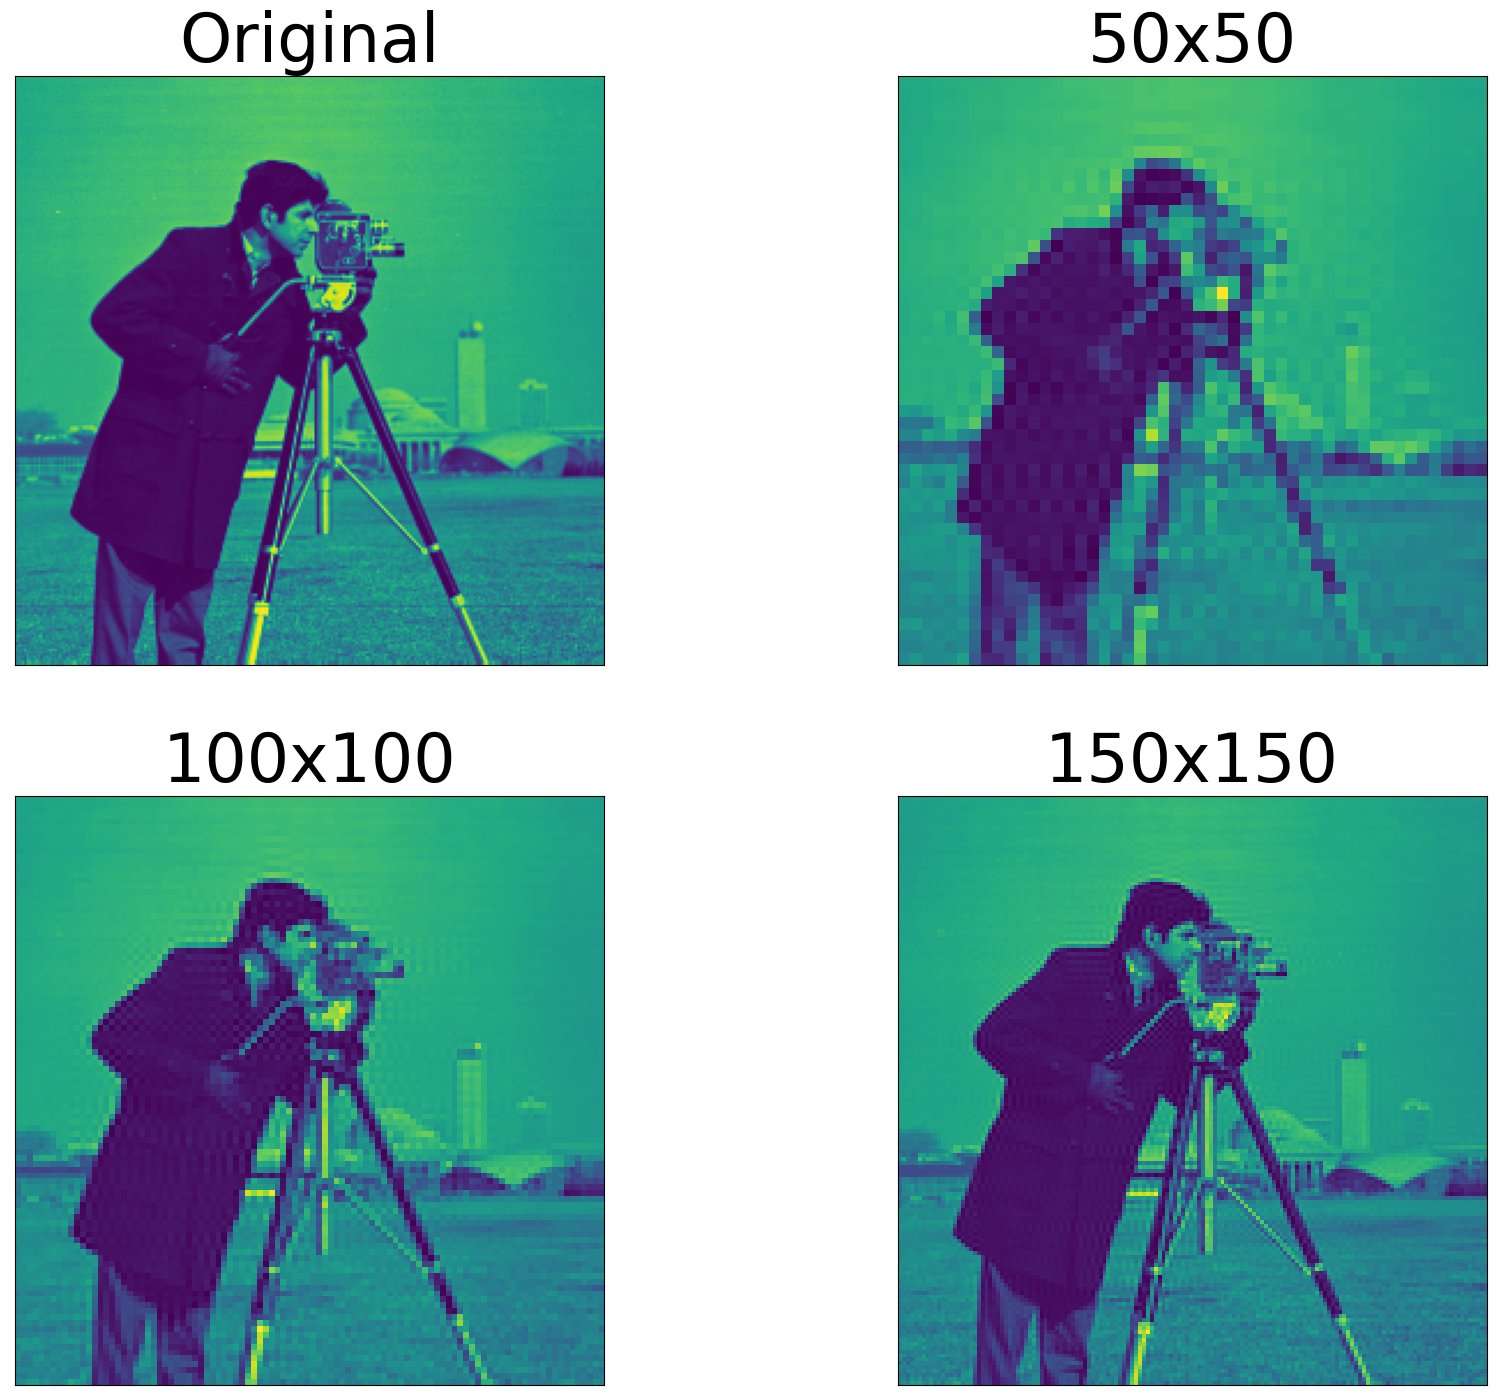

In [12]:
num_1 = 50

num_2 = 100

num_3 = 150

inv_dct_1 = idctn(dct_coeffs[0:num_1,0:num_1], norm='ortho')

inv_dct_2 = idctn(dct_coeffs[0:num_2,0:num_2], norm='ortho')

inv_dct_3 = idctn(dct_coeffs[0:num_3,0:num_3], norm='ortho')

fig = plt.figure(figsize=(20,15))
plt.subplot(2,2,1)
imp.plot_img(abs(image),'Original')
plt.subplot(2,2,2)
imp.plot_img(abs(inv_dct_1),'50x50')
plt.subplot(2,2,3)
imp.plot_img(abs(inv_dct_2),'100x100')
plt.subplot(2,2,4)
imp.plot_img(abs(inv_dct_3),'150x150')
plt.tight_layout()